In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
#for dirname, _, filenames in os.walk('/kaggle/input'):
#    for filename in filenames:
#        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session


import cv2
import matplotlib.pyplot as plt
from glob import glob
from PIL import Image

def imshow_cv2(img):
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

def str2list(s):
    return list(map(float, s.split()))



In [2]:
def score(solution, submission, debug_item=False):
    """
    this metric computes average precision and recall in theet detection
    """
    # TODO: You likely want to delete the row ID column, which Kaggle's system uses to align
    # the solution and submission before passing these dataframes to score().
    del solution['id']
    del submission['id']

    if submission.isnull().values.any():
        raise ParticipantVisibleError("Missing data in submission file")

    average_recall = 0
    average_precision = 0
    for i in range(len(solution )):
                bbox = solution['bbox'][i]
                
                theet=submission['bbox'][i]
                
                bbox=str2list(bbox)
                bbox=np.array(bbox).reshape(-1,4)
                
                theet=str2list(theet)
                theet = np.array(theet).reshape(-1,2).T
            
                true_positive = 0
               

                for j in range(len(bbox)):
                    x_min, y_min, x_max, y_max = bbox[j]
                    dx = (theet[0,:] - x_min) > 0
                    dx &= (x_max - theet[0,:]) > 0
                    dy = (theet[1,:] - y_min) > 0
                    dy &= (y_max - theet[1,:]) > 0
                    if(np.where(dx & dy)[0].shape[0]==1):
                        true_positive+=1

                false_positive=theet.shape[1]-true_positive    
                if(debug_item):
                    print('# of teeth=', len(bbox),', TP=',true_positive,', FP=',false_positive,': precision=',true_positive/theet.shape[1],' recall=',true_positive/len(bbox) )
                average_recall+=(true_positive/len(bbox))
                average_precision+=(true_positive/theet.shape[1])
        
    average_recall=average_recall/len(solution)
    average_precision=average_precision/len(solution)
    return average_recall,average_precision

In [3]:
# dummy function for theet detection
# (now it returns random coordinates for debugging only)
def find_gear_theet(img):
    h, w = img.shape[:2]
    num_theets=50
    random_x_positions = np.random.randint(0,h,num_theets)
    random_y_positions = np.random.randint(0,w,num_theets)
    random_positions=np.vstack((random_x_positions,random_y_positions)).T
    return random_positions

theet coordinates:
 [[418 310]
 [375 496]
 [508 557]
 [228 317]
 [306 619]
 [171  12]
 [477  18]
 [473 638]
 [ 96 255]
 [101 524]
 [486 244]
 [202 567]
 [335 247]
 [359  67]
 [ 20 539]
 [ 54  84]
 [112 325]
 [ 15 277]
 [404 278]
 [483 527]
 [ 90 257]
 [171 184]
 [263 259]
 [243   9]
 [438 393]
 [555  99]
 [428 622]
 [127 178]
 [367 338]
 [362 449]
 [505 302]
 [114  73]
 [229 104]
 [ 41 140]
 [482 544]
 [416 369]
 [433 175]
 [ 20 392]
 [566 233]
 [575 304]
 [284 297]
 [182  20]
 [ 22 421]
 [ 17 212]
 [156  62]
 [327  82]
 [325  16]
 [228  92]
 [203  96]
 [429 229]]
theet coordinates:
 [[205  72]
 [164 534]
 [204 466]
 [143 452]
 [554 494]
 [ 39  18]
 [ 92 171]
 [395 134]
 [531 319]
 [295 455]
 [294 280]
 [ 41 192]
 [446 635]
 [547 635]
 [225 215]
 [160 360]
 [486 111]
 [337 167]
 [ 88 334]
 [355 555]
 [480  70]
 [ 54 332]
 [235  66]
 [344 257]
 [183 569]
 [464 602]
 [255 250]
 [266  57]
 [401   4]
 [448 345]
 [ 97 387]
 [283  67]
 [236 224]
 [144 375]
 [426 605]
 [ 59  44]
 [400 292]
 [

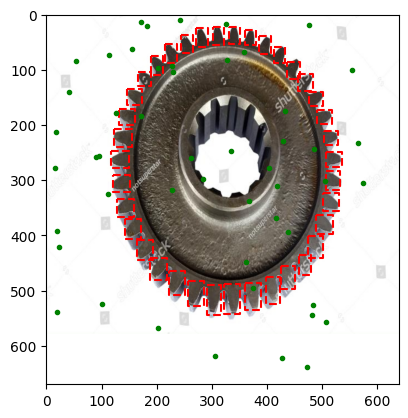

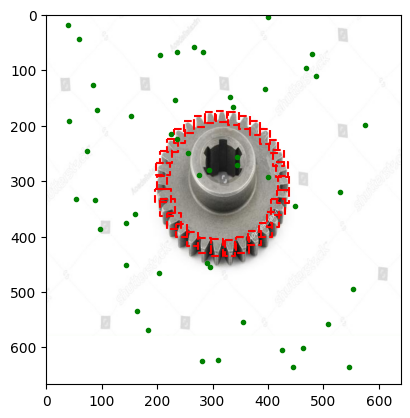

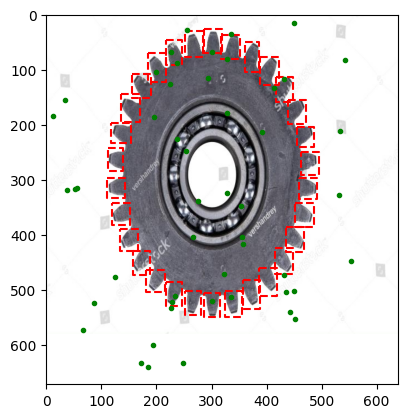

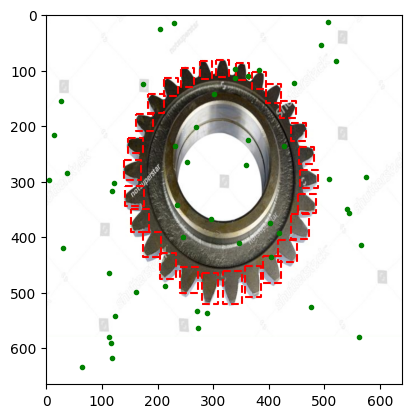

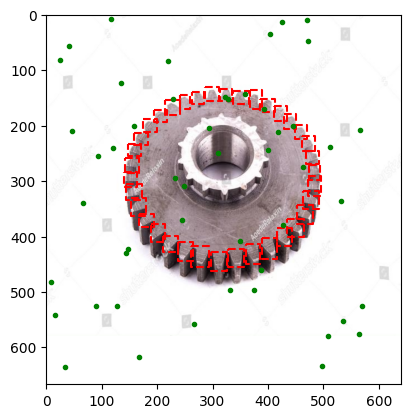

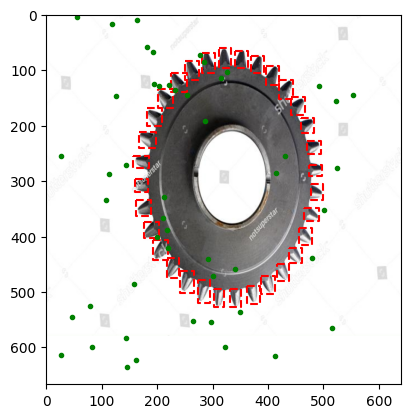

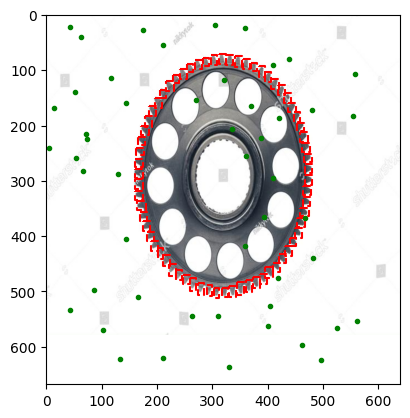

In [ ]:
# test visualization and scoring metric of training set

#TODO
# modify find_gear_theet to implement detector
# loop on images in the test folder 
# submit the .csv to the challenge

train_PATH='./data/train'
df = pd.read_csv(os.path.join(train_PATH,'annotation.csv'))
solution_df = {'id': [], 'bbox': []}
for i in range(len(df)): # loop over training images
    path=os.path.join(train_PATH,df['id'][i])
    img = cv2.imread(path)
    
    #plot gear image and annotated bounding boxes around thetheet
    plt.figure()
    imshow_cv2(img)
    bbox = df['bbox'][i]
    bbox=str2list(bbox)
    bbox=np.array(bbox).reshape(-1,4)
    
    for j in range(len(bbox)):
        x_min, y_min, x_max, y_max = bbox[j]
        plt.plot([x_min,x_max,x_max,x_min,x_min],[y_min,y_min,y_max,y_max,y_min],'r--')

    # DECTOR TO BE DESIGNED
    theet = find_gear_theet(img)

    
    # plot theer coordinates for debugging
    plt.plot(theet[:,0],theet[:,1],'g.')

    # create solution csv for scoring
    solution_df['id'].append(df['id'][i])
    #flatten teeth coordinates to string for csv logging
    theet = " ".join(map(str, theet.flatten()))
    solution_df['bbox'].append(theet)
    

pd.DataFrame(solution_df).to_csv('train_solution.csv', index=False)

sf = pd.read_csv('train_solution.csv')
average_recall, average_precision = score(df,sf,debug_item=True)
print('Recall=%.3f, Precision=%.3f'%(average_recall,average_precision))

